You have at your disposal 100000 images of human faces, and their occlusion label.
The goal of this challenge is to regress the percentage of the face that is occluded.
We also want to have similar performances on female and male, the gender label is given for the train database

Below is the formula of the evaluation score

$$
 Err = \frac{\sum_{i}{w_i(p_i - GT_i)^2}}{\sum_{i}{w_i}}, w_i = \frac{1}{30} + GT_i
$$

$$
Score = \frac{Err_F + Err_M}{2} + \left | Err_F - Err_M \right |
$$

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import OrderedDict

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

### Load dataframes

In [2]:
df_train = pd.read_csv("occlusion_datasets/train.csv", delimiter=',')
df_test = pd.read_csv("occlusion_datasets/test_students.csv", delimiter=',')

image_dir = "crops/Crop_224_5fp_100K"

In [3]:
df_train.head()

,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [4]:
df_test.head()

,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


#### Remove nan values

In [4]:
df_train = df_train.dropna()
df_test = df_test.dropna()

### Split Dataframe in train and val

In [5]:
df_val = df_train.loc[:20000].reset_index()
df_train = df_train.loc[20000:].reset_index()

In [6]:
len(df_train), len(df_val), len(df_test)

(80000, 20001, 29980)

### Check that all images are read correctly

In [8]:
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    try:
        filename = df_train.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

for idx, row in tqdm(df_val.iterrows(), total=len(df_val)):
    try:
        filename = df_val.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)
        
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    try:
        filename = df_test.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

100%|██████████| 29980/29980 [00:15<00:00, 1953.07it/s]


### Display random images

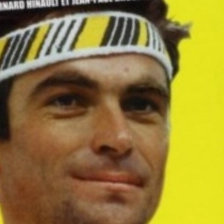

database3/database3/m.01pvzr/80-FaceId-0_align.webp 0.180283 1.0


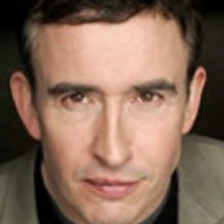

database3/database3/m.01nfys/86-FaceId-0_align.webp 0.014122 1.0


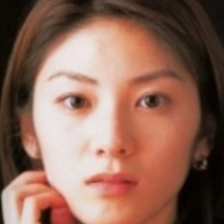

database3/database3/m.0281bfh/81-FaceId-0_align.webp 0.053277 0.0


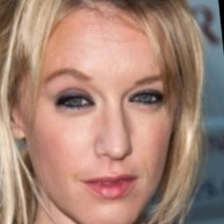

database3/database3/m.027v_n/69-FaceId-0_align.webp 0.12941 0.0


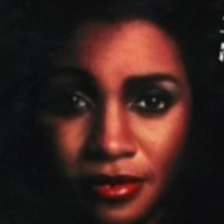

database3/database3/m.01lgkxz/54-FaceId-0_align.webp 0.039375 0.0


In [9]:
for idx, row in df_train.sample(frac=1)[:5].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

### Make Dataset and Dataloader

In [10]:
class Dataset(torch.utils.data.Dataset):
    'Characterizes a dataset for PyTorch'
    def __init__(self, df, image_dir, training=True):
         'Initialization'
         self.training = training
         self.image_dir = image_dir
         self.df = df
         self.transform = transforms.ToTensor()
         
    def __len__(self):
        'Denotes the total number of samples'
        return len(self.df)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample
        row = self.df.loc[index]
        filename = row['filename']

        # Load data and get label
        img = Image.open(f"{image_dir}/{filename}")

        X = self.transform(img)

        if self.training:
            y = row['FaceOcclusion']
            y = np.float32(y)
            gender = row['gender']
            return X, y, gender, filename
        else:
            y = None
            gender = None
            return X, filename

In [22]:
training_set = Dataset(df_train, image_dir)
validation_set = Dataset(df_val, image_dir)
test_set = Dataset(df_test, image_dir, training=False)

params_train = {'batch_size': 64,
          'shuffle': True,
          'num_workers': 0}

params_val = {'batch_size': 64,
          'shuffle': False,
          'num_workers': 0}

training_generator = torch.utils.data.DataLoader(training_set, **params_train)
validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)
test_generator = torch.utils.data.DataLoader(test_set, **params_val)

### Create naive model

In [77]:
dino_model = torch.hub.load(
    'facebookresearch/dinov2',
    'dinov2_vitb14'
)
dino_model

Using cache found in /Users/julienniol/.cache/torch/hub/facebookresearch_dinov2_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((768,), eps=1

In [59]:
class TrainModel(nn.Module):

    def __init__(self, dino_model, dropout=0.1):
        super().__init__()

        self.dino_model = dino_model
        self.dino_model.eval()

        for param in self.dino_model.parameters():
            param.requires_grad = False

        self.norm = nn.LayerNorm(768)

        self.mlp = nn.Sequential(
            nn.Linear(768, 256),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        with torch.no_grad():
            embedding = self.dino_model(x)

        embedding = self.norm(embedding)

        output = self.mlp(embedding)

        return torch.sigmoid(output)

In [60]:
model = TrainModel(dino_model, 0.1)

#### Count number of parameters

In [61]:
from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_trainable_params = 0
    total_params = 0
    for name, parameter in model.named_parameters():
        params = parameter.numel()
        total_params += params
        if not parameter.requires_grad:
            continue
        table.add_row([name, params])
        total_trainable_params += params
    print(table)
    print(f"Total Trainable Params: {total_trainable_params}")
    print(f"Total Params: {total_params}")
    
count_parameters(model)

+--------------+------------+
|   Modules    | Parameters |
+--------------+------------+
| norm.weight  |    768     |
|  norm.bias   |    768     |
| mlp.0.weight |   196608   |
|  mlp.0.bias  |    256     |
| mlp.3.weight |   16384    |
|  mlp.3.bias  |     64     |
| mlp.6.weight |     64     |
|  mlp.6.bias  |     1      |
+--------------+------------+
Total Trainable Params: 214913
Total Params: 86795393


### Loss and optimizer

In [62]:
loss_fn = nn.MSELoss()

In [63]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Train naive model

In [64]:
# CUDA for PyTorch
use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available()
device = torch.device("mps" if use_mps else "cpu")
#torch.backends.cudnn.benchmark = True

model = model.to(device)

#### Fit on train split

In [ ]:
num_epochs = 10

for n in range(num_epochs):
    print(f"Epoch {n+1}")
    for batch_idx, (X, y, gender, filename) in (pbar := tqdm(enumerate(training_generator), total=len(training_generator))):
        # Transfer to GPU
        X, y = X.to(device), y.to(device)
        y = y.view(-1, 1)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        if loss.isnan():
            print(filename)
            print('label', y)
            print('y_pred', y_pred)
            break

        pbar.set_description(f"Loss: {loss.item():.4f}")
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

Epoch 1


Loss: 0.0039: 100%|██████████| 1250/1250 [18:57<00:00,  1.10it/s]


## Evaluate metric on validation split

In [66]:
def error_fn(df):
    pred = df.loc[:, "pred"]
    ground_truth = df.loc[:, "target"]
    weight = 1/30 + ground_truth

    return np.sum(((pred - ground_truth)**2) * weight, axis=0) / np.sum(weight, axis=0)

def metric_fn(female, male):
    err_male = error_fn(male)
    err_female = error_fn(female)
    return (err_male + err_female) / 2 + abs(err_male - err_female)

In [79]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, y, gender, filename) in tqdm(enumerate(validation_generator), total=len(validation_generator)):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        for i in range(len(X)):

            results_list.append({'filename': filename[i],
                                 'pred': float(y_pred[i]),
                                  'target': float(y[i]),
                                  'gender': float(gender[i]),
                                  'error' : float(torch.abs(y_pred[i]-y[i]))
                                 })
results_df = pd.DataFrame(results_list)

100%|██████████| 313/313 [06:17<00:00,  1.21s/it]


In [80]:
results_df.head()

,filename,pred,target,gender,error
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.028661,0.024005,1.0,0.004656
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.012321,0.030028,1.0,0.017707
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.090256,0.009984,0.0,0.080272
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.024586,0.255016,1.0,0.230430
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.065394,0.252091,1.0,0.186697


<Axes: >

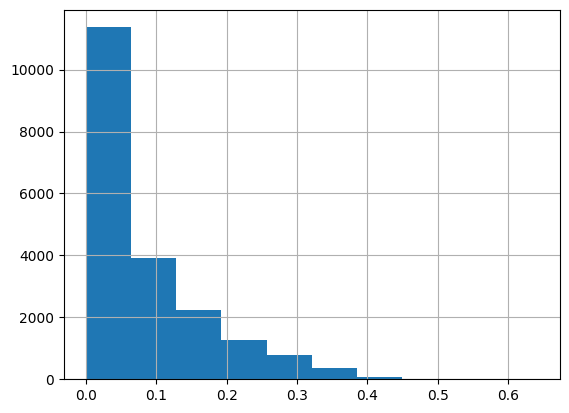

In [88]:
import matplotlib.pyplot as plt
results_df['target'].hist()

<Axes: >

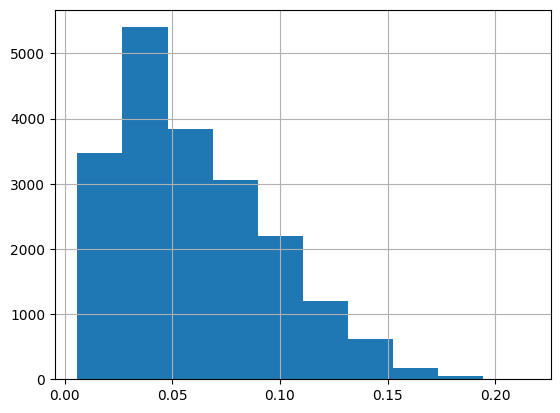

In [81]:
import matplotlib.pyplot as plt
results_df['pred'].hist()


In [82]:
results_male = results_df.loc[results_df["gender"] == 1.0]
results_female = results_df.loc[results_df["gender"] == 0.0]

In [83]:
metric_fn(results_male, results_female)

np.float64(0.017946520881300027)

### Evaluate error repartition

In [109]:
results_df['bin'] = np.floor(results_df['target']*20)
error_df = results_df[['bin','error']]

In [126]:
mae = error_df.groupby(['bin'])['error'].mean()

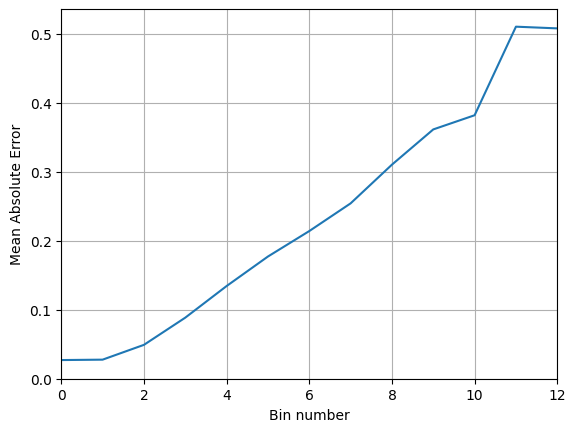

In [128]:
plt.plot(mae)
plt.xlabel("Bin number")
plt.ylabel("Mean Absolute Error")
plt.xlim((0,max(error_df['bin'])))
plt.ylim((0,max(error_df['error'])))
plt.grid()
plt.show()

In [130]:
rmse = error_df.groupby(['bin'])['error'].std()

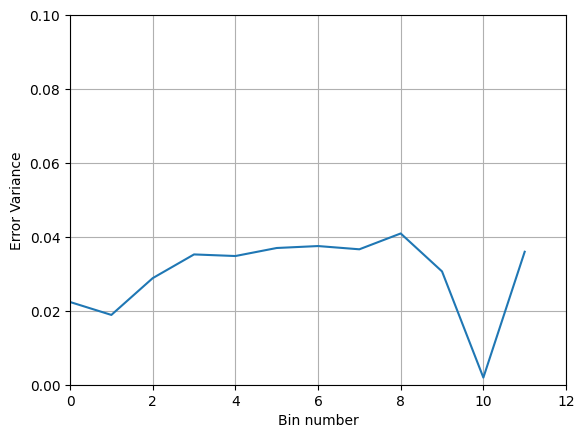

In [132]:
plt.plot(rmse)
plt.xlabel("Bin number")
plt.ylabel("Error Variance")
plt.xlim((0,max(error_df['bin'])))
plt.ylim((0,0.1))
plt.grid()
plt.show()

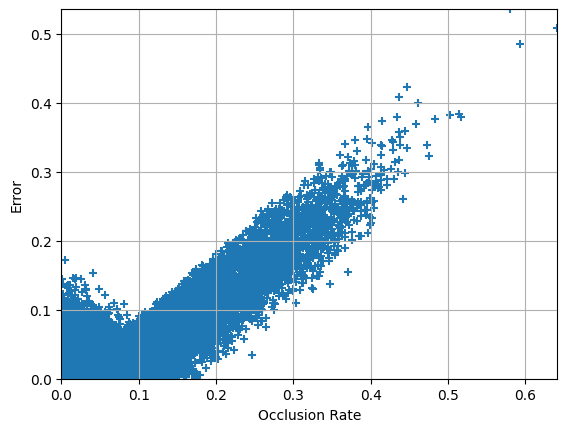

In [133]:
plt.scatter(x=results_df['target'],y=results_df['error'], marker='+')
plt.xlabel("Occlusion Rate")
plt.ylabel("Error")
plt.xlim((0,max(results_df['target'])))
plt.ylim((0,max(results_df['error'])))
plt.grid()
plt.show()

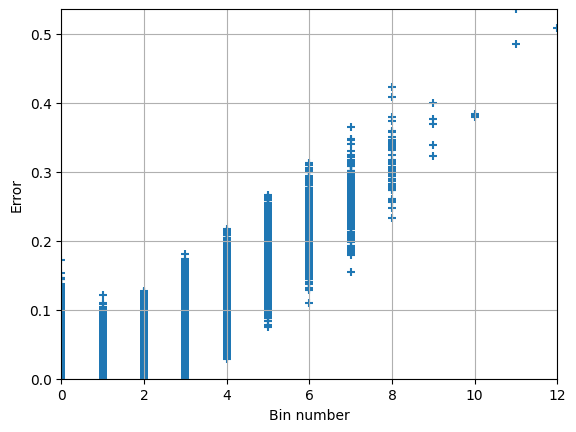

In [134]:
plt.scatter(x=error_df['bin'],y=error_df['error'], marker='+')
plt.xlabel("Bin number")
plt.ylabel("Error")
plt.xlim((0,max(error_df['bin'])))
plt.ylim((0,max(error_df['error'])))
plt.grid()
plt.show()

### Make predictions on test dataset

In [72]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, filename) in tqdm(enumerate(test_generator), total=len(test_generator)):
        X = X.to(device)
        y_pred = model(X)
    
        for i in range(len(X)):
            results_list.append({'filename': filename[i],
                                 'FaceOcclusion': float(y_pred[i]),
                                 })
results_df = pd.DataFrame(results_list)

100%|██████████| 469/469 [07:09<00:00,  1.09it/s]


In [75]:
results_df.head()

,filename,FaceOcclusion,gender
0,database3/database3/m.0256vn/81-FaceId-0_align...,0.030362,x
1,database3/database3/m.01dgwg/29-FaceId-0_align...,0.029594,x
2,database3/database3/m.02l0nk/72-FaceId-0_align...,0.085352,x
3,database3/database3/m.026jp3/94-FaceId-1_align...,0.035638,x
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...,0.054949,x


### Export predictions
Note: We need to add a dummy 'gender' column for the hfactory upload.

In [76]:
results_df['gender'] = 'x'
results_df.to_csv("test_predictions.csv", sep=',', index=False)